In [1]:
import os
repo = 'boston-marathons'
counter = 0
max_depth = 50
current = os.getcwd()
while True:
    current_tmp = os.path.basename(os.getcwd())
    if current_tmp == repo:
        print(f"Main dir found: {os.getcwd()}")
        break
    else:
        os.chdir("..")
        counter += 1
        if counter >= max_depth:
            print(f"Reached {max_depth} levels up — '{repo}' not found.")
            os.chdir(current)
            print(f"Current path: {current}")
            break

Main dir found: D:\Scripts\Data Science\projekty\repo\boston-marathons


In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math as math
from scripts.mappings import continent_colors

In [3]:
df = pd.read_csv('./data/clean/boston_features.csv')

In [4]:
df.head()

,Name,M/F,Age,Age Group,Country,Continent,City,Pace,5K,10K,15K,20K,25K,30K,35K,40K,Official Time,Year,Place_Year,Place_Global
0,"Desisa, Lelisa",M,25,22–25,ETH,Africa,Ambo,3.065431,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.044167,2.154722,2015,1,1
1,"Kirui, Geoffrey",M,24,22–25,KEN,Africa,Keringet,3.075787,0.256944,0.507778,0.762222,1.020833,1.283056,1.550278,1.805278,2.048056,2.160278,2017,1,2
2,"Tsegay, Yemane Adhane",M,30,30–33,ETH,Africa,Addis Ababa,3.086144,0.245278,0.495278,0.749444,1.007778,1.268611,1.533056,1.799722,2.045000,2.163333,2015,2,3
3,"Rupp, Galen",M,30,30–33,USA,North America,Portland,3.086144,0.256667,0.507500,0.762222,1.020833,1.283056,1.550278,1.805278,2.053889,2.166111,2017,2,4
4,"Chebet, Wilson",M,29,26–29,KEN,Africa,Marakwet,3.096500,0.245278,0.495278,0.749167,1.008056,1.268611,1.533333,1.799722,2.050278,2.172778,2015,3,5


In [30]:
plt.style.use('seaborn-v0_8-whitegrid')

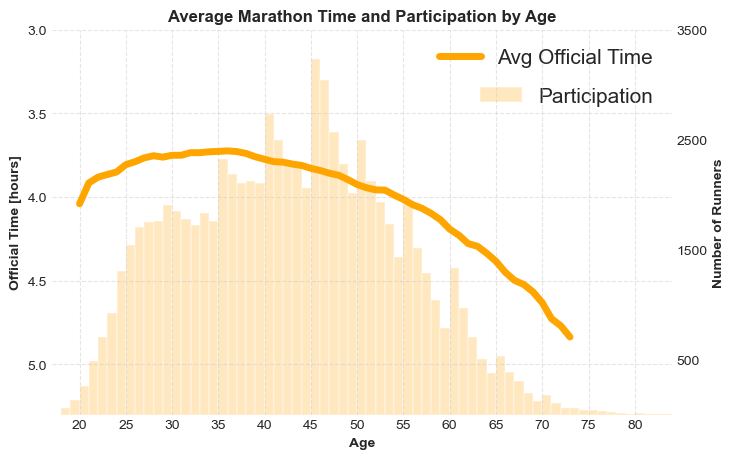

In [260]:
fig, ax1 = plt.subplots(figsize=(8,5))
ax2 = ax1.twinx()

plot_data = df.groupby(["Age"])["Official Time"].mean().reset_index().sort_values(by="Age")
plot_data = plot_data[plot_data["Age"] < 74]

plot_x = plot_data["Age"]
plot_y = plot_data["Official Time"].rolling(3).mean()

hist_data = df["Age"]

ax1.plot(plot_x, plot_y, color="orange", linewidth=5, label='Avg Official Time')

ax1.set_title("Average Marathon Time and Participation by Age", weight='bold')
ax1.set_xlabel("Age", weight='bold')
ax1.set_ylabel("Official Time [hours]", weight='bold')
ax1.set_xlim(17,df["Age"].max())
ax1.set_xticks(range(20,df["Age"].max(),5))
ax1.set_ylim(3,5.3)
ax1.set_yticks(np.arange(3.0,5.5,0.5))
ax1.invert_yaxis()
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.set_zorder(3)
ax1.patch.set_visible(False)


ax2.hist(hist_data, bins=range(18,85), color='orange', alpha=0.25, edgecolor='white', linewidth=1.5, label='Participation')

ax2.set_ylabel("Number of Runners", weight='bold')
ax2.set_ylim(0,3500)
ax2.set_yticks(range(500,3501,1000))
ax2.grid(False)
ax2.set_zorder(2)
ax2.patch.set_visible(True)

ax1.legend(fontsize=15, loc='upper right', bbox_to_anchor=(1, 1))
ax2.legend(fontsize=15, loc='upper right', bbox_to_anchor=(1, 0.9))

spines = ["top", "bottom", "left", "right"]
for spine in spines:
    ax1.spines[spine].set_visible(False)
    ax2.spines[spine].set_visible(False)

# plt.savefig("test/chart_2.png", dpi=300, bbox_inches='tight')
plt.show()